In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.cm as cm
import statsmodels.api as sm


In [2]:
import os, zipfile, requests
from tqdm.notebook import tqdm

DATA_URL = "https://zenodo.org/records/22163061/files/data.zip?download=1"

if not os.path.exists("data"):
    print("Downloading data from Zenodo...")
    resp = requests.get(DATA_URL, stream=True)
    total = int(resp.headers.get("content-length", 0))

    with open("data.zip", "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as bar:
        for chunk in resp.iter_content(chunk_size=8192):
            f.write(chunk)
            bar.update(len(chunk))

    print("Extracting...")
    with zipfile.ZipFile("data.zip", "r") as z:
        z.extractall(".")
    os.remove("data.zip")
    print("Done.")
else:
    print("data/ already exists, skipping download.")

  0%|          | 0.00/123M [00:00<?, ?B/s]

Extracting...
Done.


In [3]:
from utils import *

In [4]:
df_master = pd.read_pickle('data/pouring_behavioural_data.pkl')

# Convert grouping vars to categorical
cat_cols = ["participant", "task", "container", "vessel"]
for c in cat_cols:
    df_master[c] = df_master[c].astype("category")


In [5]:
#get pt_order by their ascending fill level. take Mug as reference vessel
df_pivot_mean = df_master.pivot_table(index=["participant", "vessel"], 
                                  values="dist_rim").reset_index()
pt_order_ascending_fills = df_pivot_mean[df_pivot_mean['vessel']=='Mug'].sort_values('dist_rim', ascending=False)['participant'].tolist()

colors = cm.winter_r(np.linspace(0, 1, len(pt_order_ascending_fills)))
subject_color = dict(zip(pt_order_ascending_fills, colors))

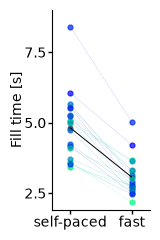

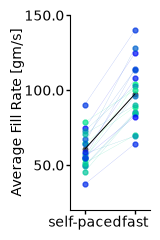

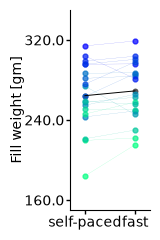

In [6]:
def plot_between_task(measure, ylabel, ylim):
    fig, ax = plt.subplots(figsize=(1.7, 2.5))

    # Compute subject-wise means per vessel
    subj_vessel_means = (df_master.groupby(["participant", "task"], observed=True)[measure].mean().reset_index())

    # Ensure plotting order uses the categorical order
    task_order = ['self-paced', 'fast',]
    x_positions_label = [1,2]

    # Pivot to wide for easier line plotting
    wide = subj_vessel_means.pivot(index="participant", columns="task", values=measure)
    wide = wide[task_order]  # enforce order

    # Plot each subject line
    for subj, row in wide.iterrows():
        ax.plot(x_positions_label, row.values, marker="o", markersize=3.5, linewidth=0.1, alpha=0.7, color=subject_color[subj])

    # Overlay grand mean (thicker line)
    grand = df_master.groupby("task", observed=True)[measure].mean().reindex(task_order)
    ax.plot( x_positions_label, grand.values, linewidth=0.7, color="black")
    ax.scatter( x_positions_label, grand.values,  c='#555555', marker='o', s=18 , zorder=1, linewidths=0., )

    ax.set_ylabel(ylabel, labelpad=0)
    ax.set_ylim(*ylim) 
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.tick_params(pad=1)
    ax.set_xlim(0.7, 2.3)
    ax.set_xticks(x_positions_label, task_order)
    simpleaxis(ax, direction = 'out', tickLen=3)
    plt.show()
    plt.close('all')

plot_between_task(measure='fill_time', ylabel='Fill time [s]', ylim=(1.9, 9))
plot_between_task(measure='fill_rate_avg', ylabel='Average Fill Rate [gm/s]',  ylim=(20, 150))
plot_between_task(measure='fill_weight', ylabel='Fill weight [gm]',  ylim=(150, 350))

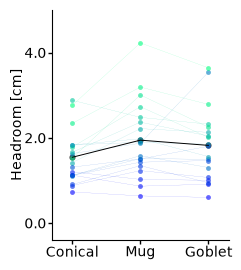

In [7]:
# Compute subject-wise means per vessel
subj_vessel_means = (
    df_master.groupby(["participant", "vessel"], observed=True)["dist_rim"]
      .mean()
      .reset_index()
)

x_positions_label = [1,2,3]

# Pivot to wide for easier line plotting
wide = subj_vessel_means.pivot(index="participant", columns="vessel", values="dist_rim")
wide = wide[vessel_list]  # enforce order

fig, ax = plt.subplots(
    figsize=(2.5, 2.8)
    )

# Plot each subject line
for subj, row in wide.iterrows():
    ax.plot(x_positions_label, row.values, marker="o", markersize=3.5, linewidth=0.1, alpha=0.6, color=subject_color[subj], markeredgewidth=0.)



# Overlay grand mean (thicker line)
grand = df_master.groupby("vessel", observed=True)["dist_rim"].mean().reindex(vessel_list)
ax.plot(x_positions_label, grand.values, linewidth=0.7, color="black")
ax.scatter(x_positions_label, grand.values, c='#555555', marker='o',s=20 ,    zorder=1,    linewidths=0.,
)


# ax.set_xlabel("vessel")
ax.set_ylabel("Headroom [cm]", labelpad=0)
ax.set_ylim(-0.4, 5) 
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
ax.tick_params(pad=1)
ax.set_xlim(0.7, 3.3)
ax.set_xticks(x_positions_label, vessel_list)
simpleaxis(ax, direction = 'out', tickLen=3)
plt.show()

plt.close('all')

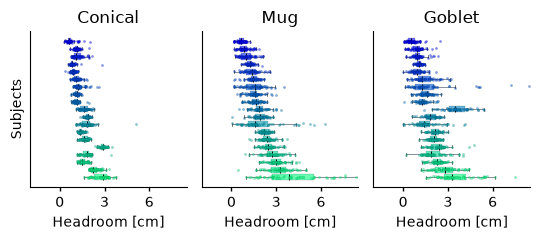

In [8]:
# Plotting every data point of headroom
fig, axs = plt.subplots(1, 3, figsize=(5.5,2.5 ),sharex=True)


for i, vessel_name in enumerate(vessel_list):
    ax = axs[i]
    df_vessel = df_master[df_master['vessel'] == vessel_name]
    for s_idx, subj in enumerate(pt_order_ascending_fills):
        df_subj = df_vessel[df_vessel['participant'] == subj]
        data = df_subj['dist_rim'].dropna()
        subj_color = subject_color[subj]
        pos = s_idx

        # Boxplot
        bp = ax.boxplot(
            data,
            positions=[pos],
            widths=0.8,
            vert=False,
            patch_artist=True,
            showfliers=False,
            manage_ticks=False,
            whiskerprops=dict(color='#2C3E50', linewidth=0.4),
            capprops=dict(color='black', linewidth=0.4),
            boxprops=dict(linewidth=0.2, edgecolor='#2C3E50'),
            medianprops=dict(color='black', linewidth=.7),
        )

        for patch in bp['boxes']:
            patch.set_facecolor(subj_color)   # single neutral color
            patch.set_alpha(0.6)
            patch.set_edgecolor('#2C3E50')

        # Jittered points
        y_jitter = np.random.normal(pos, 0.07, size=len(data))
        ax.scatter(data,y_jitter,color=subj_color, s=3.,linewidth=0.1, alpha=0.5,  edgecolor='k', zorder=3 )

    # Axis formatting
    ax.set_title(vessel_name)
    ax.set_yticks([])
    ax.set_xlim(-2, 8.5)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))

    if i == 0:
        ax.set_ylabel("Subjects")
    ax.set_xlabel("Headroom [cm]")
    simpleaxis(ax, tickLen=3, direction='out')

plt.tight_layout()
plt.show()
plt.close('all')

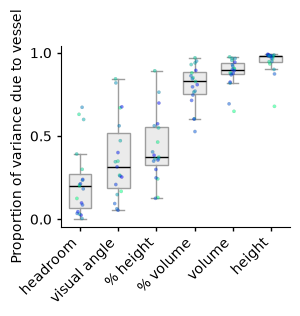

In [9]:
# invariance
rng = np.random.default_rng(seed=42)


df_master_invariance = df_master.drop(df_master[df_master['visual_angle'].isna()].index)


subject_col, vessel_col = 'participant', 'vessel'
measures = {
    'fill_weight':'volume','fill_height':'height','visual_angle':'visual angle',
    'fill_height_percentage':'% height','fill_weight_percentage':'% volume',
    'dist_rim':'headroom',
}

def vessel_fraction_per_subject(d, m):
    d[m] = d[m].astype(float)
    out = {}
    for subj, ds in d.groupby(subject_col):
        subj_mean = ds[m].mean()
        cell_means = ds.groupby(vessel_col)[m].transform('mean')
        ss_vessel = ((cell_means - subj_mean)**2).sum()      # vessel moves this subject
        ss_res = ((ds[m] - cell_means)**2).sum()          # trial noise within vessel
        tot = ss_vessel + ss_res
        if tot > 0:
            out[subj] = ss_vessel / tot
    return out

rows = []
for m, label in measures.items():
    for subj, frac in vessel_fraction_per_subject(df_master, m).items():
        rows.append({'participant': subj, 'measure': label, 'frac_vessel': frac})

cf = pd.DataFrame(rows)
summary = cf.groupby('measure')['frac_vessel'].median().sort_values()

order = summary.index.tolist()
data = [cf[cf['measure'] == lbl]['frac_vessel'].values for lbl in order]

fig, ax = plt.subplots(figsize=(3.1, 2.9))

for i, lbl in enumerate(order):
    sub = cf[cf['measure'] == lbl]
    xi = (i + 1) + rng.uniform(-0.1, 0.1, size=len(sub))
    colors = [subject_color[s] for s in sub['participant']]
    ax.scatter(xi, sub['frac_vessel'].values, s=6, c=colors, alpha=0.5,
               zorder=3, edgecolor='k', linewidth=0.07)

bp = ax.boxplot(data, vert=True, widths=0.6, patch_artist=True,
                showfliers=False, medianprops=dict(color='black', linewidth=1.),
                boxprops=dict(facecolor='#ebebeb', edgecolor='#9e9e9e', alpha=1.),
                whiskerprops=dict(color='#9e9e9e'), capprops=dict(color='#9e9e9e'))

ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order, rotation=45, ha='right')
ax.yaxis.set_ticks([0, 0.5, 1.])
ax.set_ylabel('Proportion of variance due to vessel')
simpleaxis(ax, tickLen=3, direction='out')

plt.show()
plt.close('all')

In [10]:
#aggregate fill level and time for each combo, each pt, each task to get their average levels.. i.e average of 10 trials

df_variability = df_master.groupby(['participant', 'task', 'container', 'vessel']).agg({'dist_rim': ['mean', 'std'],}).reset_index()

df_variability.columns = [f'{col[0]}_{col[1]}' if col[1] else col[0] for col in df_variability.columns]

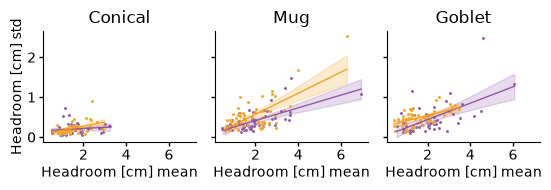

In [11]:


def get_regression(x, y, intercept=False):
    # Sort x for clean plotting
    sort_idx = np.argsort(x)
    x_sorted = x[sort_idx]
    y_sorted = y[sort_idx]

    X = x_sorted.reshape(-1, 1)

    if not intercept:
        X = x_sorted.reshape(-1, 1)
    else:
        X = sm.add_constant(x_sorted)  # adds intercept term
        
    model = sm.OLS(y_sorted, X).fit()
    pred = model.get_prediction(X)
    ci = pred.summary_frame(alpha=0.05)  # 95% confidence
    return model, ci


fig, axs = plt.subplots(1, 3, figsize=(5.6,2.), sharey=True, sharex=True)
task_colors_dict = {'self-paced': "#884ea0",'fast':"#f39c12",}

for cid, vessel in enumerate(vessel_list):
    ax = axs[cid]
    for task in ['self-paced', 'fast']:
        x = df_variability[(df_variability['task']==task) & (df_variability['vessel']==vessel) ]['dist_rim_mean'].values
        y = df_variability[(df_variability['task']==task) & (df_variability['vessel']==vessel) ][f'dist_rim_std'].values

        mask = ~np.isnan(y) #ignore nan values
        x_clean = x[mask]
        y_clean = y[mask]

        sort_idx = np.argsort(x_clean)
        x_sorted = x_clean[sort_idx]
        y_sorted = y_clean[sort_idx]
        model, ci = get_regression(x_sorted,y_sorted, intercept=True)
        y_fit = ci["mean"]
        y_ci_lower = ci["mean_ci_lower"]
        y_ci_upper = ci["mean_ci_upper"]
        # Plot regression line
        ax.plot(x_sorted, y_fit, lw=1, color=task_colors_dict[task], alpha=0.9,label=task)
        # Plot shaded 95% CI
        ax.fill_between(x_sorted, y_ci_lower, y_ci_upper, color=task_colors_dict[task], alpha=0.2)


        # Plot scatter
        ax.scatter(x_clean, y_clean, alpha=0.9, s=5, 
                       edgecolor='white', linewidth=0.1, color=task_colors_dict[task])

        ax.set_xlabel("Headroom [cm] mean", labelpad=2)
        if cid==0:
            ax.set_ylabel("Headroom [cm] std", labelpad=2)

        ax.xaxis.set_ticks([2, 4, 6])
        ax.yaxis.set_ticks([0, 1, 2.])

        ax.set_title(vessel, ) 
        simpleaxis(ax, constrained=False, direction='out', tickLen=3)
        ax.tick_params(pad=2)

plt.show()
plt.close('all')

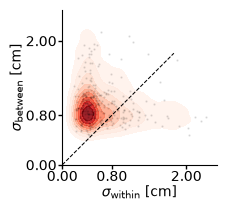

In [12]:

n_boot = 20000
n_trials = 20

within_vals = []
between_vals = []

subjects = df_master['participant'].unique()

for _ in range(n_boot):
    
    # pick a random subject
    s = np.random.choice(subjects)
    
    df_s = df_master[df_master['participant'] == s]
    df_others = df_master[df_master['participant'] != s]
    

    # sample trials
    within_sample = df_s['dist_rim'].sample(n=n_trials, replace=False).values
    between_sample = df_others['dist_rim'].sample(n=n_trials, replace=False).values
    
    # compute variability (SD)
    within_vals.append(np.std(within_sample))
    between_vals.append(np.std(between_sample))

within_vals = np.array(within_vals)
between_vals = np.array(between_vals)




fig, ax = plt.subplots(figsize=(2., 3.))

sns.kdeplot(
    x=within_vals,
    y=between_vals,
    fill=True,
    cmap=cm.Reds, 
    # cmap=cm.GnBu, 
    levels=10,
    alpha=0.9,
    # thresh=0.05
    ax=ax
)


#display only some samples of the simulation to reduce clutter
samples_to_plot = 300
rng = np.random.default_rng(seed=42)
#display only some samples of the simulation to reduce clutter
sub_samples = rng.integers(0, len(within_vals), size=samples_to_plot)
ax.scatter(within_vals[sub_samples], between_vals[sub_samples], c='k', s=0.5, alpha=0.1)


ax.plot((0.,1.8), (0.,1.8), color='k', lw=0.75, linestyle='dashed')

ax.set_xlim(0.,2.5)
ax.set_ylim(0.,2.5)

ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.xaxis.set_ticks([0, 0.8, 2])
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.yaxis.set_ticks([0, 0.8, 2])
ax.set_aspect('equal',)
ax.tick_params(pad=1)
ax.set_xlabel(r'$\sigma_\mathrm{within}$ [cm]', labelpad=1)
ax.set_ylabel(r'$\sigma_\mathrm{between}$ [cm]', labelpad=1)
simpleaxis(ax, direction = 'out', tickLen=3, constrained='False')

plt.show()
plt.close('all')




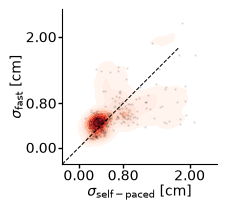

In [13]:
n_boot = 20000
n_trials = 20

selfpaced_vals = []
fast_vals = []

subjects = df_master['participant'].unique()
vessels = df_master['vessel'].unique()

for _ in range(n_boot):
    
    # pick a random subject
    s = np.random.choice(subjects)
    c =  np.random.choice(vessels)
    
    df_s_normal = df_master[(df_master['participant'] == s) & (df_master['task'] == 'self-paced')]
    df_s_fast = df_master[(df_master['participant'] == s) & (df_master['task'] == 'fast')]
    

    # sample trials
    selfpaced_sample = df_s_normal['dist_rim'].sample(n=n_trials, replace=False).values
    fast_sample = df_s_fast['dist_rim'].sample(n=n_trials, replace=False).values
    
    # compute variability (SD)
    selfpaced_vals.append(np.std(selfpaced_sample))
    fast_vals.append(np.std(fast_sample))

selfpaced_vals = np.array(selfpaced_vals)
fast_vals = np.array(fast_vals)

fig, ax = plt.subplots(figsize=(2., 3.))

sns.kdeplot(
    x=selfpaced_vals,
    y=fast_vals,
    fill=True,
    cmap=cm.Reds, 
    levels=10,
    alpha=0.9,
    ax=ax
)


#display only some samples of the simulation to reduce clutter
samples_to_plot = 300
rng = np.random.default_rng(seed=42)
#display only some samples of the simulation to reduce clutter
sub_samples = rng.integers(0, len(selfpaced_vals), size=samples_to_plot)
ax.scatter(selfpaced_vals[sub_samples], fast_vals[sub_samples], c='k', s=0.5, alpha=0.1)


ax.plot((-0.3,1.8), (-0.3,1.8), color='k', lw=0.75, linestyle='dashed')

ax.set_xlim(-0.3,2.5)
ax.set_ylim(-0.3,2.5)

ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.xaxis.set_ticks([0, 0.8, 2])
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.yaxis.set_ticks([0, 0.8, 2])
ax.set_aspect('equal',)
ax.tick_params(pad=1)
ax.set_xlabel(r'$\sigma_\mathrm{self-paced}$ [cm]', labelpad=1)
ax.set_ylabel(r'$\sigma_\mathrm{fast}$ [cm]', labelpad=1)
simpleaxis(ax, direction = 'out', tickLen=3, constrained='False')

plt.show()

In [14]:
# trajectories data

data_master_trajectories = load_saved_trajectories('data/pouring_trajectories_data.h5')


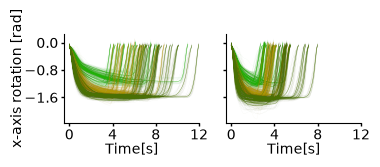

In [15]:
fig, axs = plt.subplots(1, 2
                    , figsize=(3.9,1.53), 
                    sharey=True)

for a, _task in enumerate(task_list):
    ax=axs[a]
    data_here = {}
    for ch, container in enumerate(container_list):
        label_flag = True
        for p, data_p in data_master_trajectories.items():
            data_trials_p = []
            for vessel in vessel_list:  
                combo = f'{vessel}{container}' if _task=='self-paced' else f'{vessel}{container}_{_task}'
                data_e = data_p[combo]
                data_trials = [data[:,0] for data in data_e['trajectories_full']]
                data_trials_p += data_trials
            trials_normalised = normalize_trajectories(data_trials_p)
            trials_p_mean_traj = trials_normalised.mean(axis=0)
            for gg, traj in enumerate(trials_normalised):
                if label_flag:
                    ax.plot(np.arange(len(traj))/mocap_smp_rate, traj, alpha=0.07,linewidth=0.1, color=colors_dict_all[container], label=container)
                    label_flag = False
                else:
                    ax.plot(np.arange(len(traj))/mocap_smp_rate, traj, alpha=0.1,linewidth=0.1, color=colors_dict_all[container])
            ax.plot(np.arange(len(trials_p_mean_traj))/mocap_smp_rate, trials_p_mean_traj, alpha=.8,linewidth=.3, color=colors_dict_all[container])
    simpleaxis(ax,direction='out', tickLen=2)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    ax.set_xlabel('Time[s]', labelpad=0)
    ax.set_xticks([0,4,8,12])
    ax.set_xlim(-0.5,12)
    ax.tick_params(pad=2)
axs[0].set_ylabel('x-axis rotation [rad]', labelpad=0)
plt.tight_layout()
plt.show()
plt.close('all')



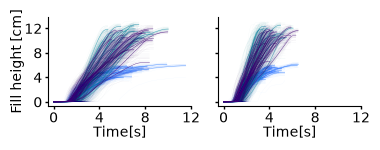

In [16]:
fig, axs = plt.subplots(1, 2
                    , figsize=(3.9,1.53), 
                    sharey=True)
max_heights = {'Conical' : 6.8, 'Mug' : 13.2, 'Goblet' : 12.6}

for a, _task in enumerate(task_list):
    ax=axs[a]
    data_here = {}
    for ch, vessel in enumerate(vessel_list):
        label_flag = True
        for p, data_p in data_master_trajectories.items():
            data_trials_p = []
            for container in container_list:  
                combo = f'{vessel}{container}' if _task=='self-paced' else f'{vessel}{container}_{_task}'
                data_e = data_p[combo]
                data_trials = [(max_heights[vessel]- data[:,1]) for data in data_e['trajectories_full']]
                data_trials_p += data_trials
            trials_normalised = normalize_trajectories(data_trials_p)
            trials_p_mean_traj = trials_normalised.mean(axis=0)
            for gg, traj in enumerate(trials_normalised):
                if label_flag:
                    ax.plot(np.arange(len(traj))/mocap_smp_rate, traj, alpha=0.07,linewidth=0.1, color=colors_dict_all[vessel], label=vessel)
                    label_flag = False
                else:
                    ax.plot(np.arange(len(traj))/mocap_smp_rate, traj, alpha=0.1,linewidth=0.1, color=colors_dict_all[vessel])
            ax.plot(np.arange(len(trials_p_mean_traj))/mocap_smp_rate, trials_p_mean_traj, alpha=.8,linewidth=.3, color=colors_dict_all[vessel])
    simpleaxis(ax,direction='out', tickLen=2)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    ax.set_xlabel('Time[s]', labelpad=0)
    ax.set_xticks([0,4,8,12])
    ax.set_xlim(-0.5,12)
    ax.tick_params(pad=2)
axs[0].set_ylabel('Fill height [cm]', labelpad=0)
plt.tight_layout()
plt.show()
plt.close('all')

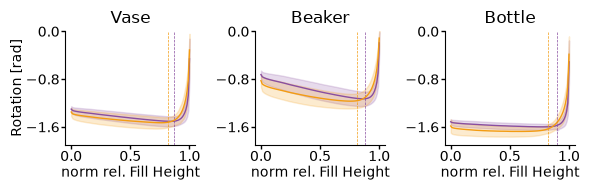

In [17]:
# fill heightrelative vs rotation NORM
x_axis = 'fill_height_relative'
y_axis = 'rotation'
t_norm = 100

cut_off_inflection_dict = {
    'Beaker':0.005,
    'Vase':0.005,
    'Bottle':0.01,
}
start_ratio = 0.7
end_ratio = 0.99

def normalize_within_signal(traj):
    _min = np.min(traj)
    _max = np.max(traj)
    traj_norm = (traj - _min)/(_max - _min)
    return traj_norm

def get_avg_traj(traj):
    mean = traj.mean(axis=0)
    std = traj.std(axis=0)
    return mean, std

fig, sp = plt.subplots(1, 3, figsize = (6,2), sharex=False, sharey=False)

for c_id, container in enumerate(['Vase', 'Beaker', 'Bottle']):
    ax = sp[c_id]
    for task in task_list:
        task_l = '' if task == 'self-paced' else '_fast'
        x_list, y_list = [],[]
        for v_id, vessel in enumerate(vessel_list):
            for pt, data_p in data_master_trajectories.items():
                exp = vessel+container+task_l
                data_e = data_p[exp]
                #x axis should be relative fill height
                x_list += [(max_heights[vessel]- i[:,1])/max_heights[vessel]  for i in data_e['trajectories_full']]
                y_list += [i[:,0] for i in data_e['trajectories_full']]
        
        common_grid = np.linspace(0, 1, t_norm)
        coupled_normalization = []
        for tid in range(len(x_list)):
            x_signal_norm = normalize_within_signal(x_list[tid])
            y_signal = y_list[tid]

            #use np interp to interpolate y wrt x on a common grid
            sort_idx = np.argsort(x_signal_norm) # interp requires sorted list.
            x_sorted = x_signal_norm[sort_idx]
            y_sorted = y_signal[sort_idx]
            
            # Interpolate onto common grid
            signal2_interp = np.interp(common_grid, x_sorted, y_sorted)
            coupled_normalization.append(signal2_interp)

        
        coupled_m, coupled_std = get_avg_traj(np.array(coupled_normalization))
            
        ax.plot(common_grid, coupled_m, color=task_colors_dict[task], linewidth=1, label=task)
        ax.fill_between(common_grid, coupled_m - coupled_std, coupled_m + coupled_std,
                        color=task_colors_dict[task], alpha=0.2)

        #find inflection point of container
        cut_off_inflection = cut_off_inflection_dict[container]

        jtvs = coupled_m[1:] - coupled_m[:-1]
        start_cut = int(start_ratio*t_norm)
        end_cut = int(end_ratio*t_norm)
        indices_inflection = np.where(jtvs[start_cut:end_cut]<cut_off_inflection)[0]
        if len(indices_inflection) > 0:
            inflection_delta = indices_inflection[-1]
        else:
            #sometimes doesn't cross 0, take the minimum
            inflection_delta = np.argmin(jtvs[start_cut:end_cut])
        inflection_point = (inflection_delta + start_cut)/t_norm


        ax.axvline(inflection_point, color=task_colors_dict[task], lw=0.5, linestyle='dashed' )

        ax.set_xlabel(f'norm rel. Fill Height', labelpad=1)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
        ax.set_ylim(-1.9, 0)
        if c_id==0:
            ax.set_ylabel(f'Rotation [rad]', labelpad=1)
        ax.tick_params(axis='both', pad=1)

    ax.set_title(container)
    simpleaxis(ax, direction='out', tickLen=3)
plt.tight_layout()

plt.show()

